# 1. Загрузка датасета для обучения кластеризации

Мы загружаем либо оригинальный файл, либо уже готовый и очищенный от артикулов, каждому классу которому уже присвоен собственный номер кластера на основе KMeans

Все расчеты проводились на 16 GB RAM, Ryzen 5 3550H (4C/8T)

In [1]:
import os
import pandas as pd

DATA_PATH = "esf_fulll_202511211949.csv"
TRAIN_PATH = "data_KNN.csv"

# Название столбца с описаниями ТРУ
DESCRIPTION_COL = "DESCRIPTION"

print("=== Загрузка данных ===")

# Если есть train.csv — загружаем его
if os.path.exists(TRAIN_PATH):
    print(f"Обнаружен {TRAIN_PATH}, загружаю TRAIN-датасет...")
    df = pd.read_csv(TRAIN_PATH)
    print("Размер датасета:", df.shape)
    print("Колонки:", df.columns.tolist())

# Если train.csv нет — загружаем файл, только 1 столбец
else:
    print(f"{TRAIN_PATH} не найден, загружаю файл {DATA_PATH} (только первый столбец)...")
    df = pd.read_csv(
        DATA_PATH,
        usecols=[0],            # берем только 1 столбец
    )
    df.columns = [DESCRIPTION_COL]  # называем столбец как нужно

    print("Размер датасета:", df.shape)
    print("Колонки:", df.columns.tolist())

print("=== Загрузка завершена ===")
# 15 seconds

=== Загрузка данных ===
data_KNN .csv не найден, загружаю файл esf_fulll_202511211949.csv (только первый столбец)...
Размер датасета: (5000000, 1)
Колонки: ['DESCRIPTION']
=== Загрузка завершена ===


# 2. Очистка и нормализация текста

Для дальнейшего улучшения качества обучения предлагается улучшить качество обучения, добавив словарь сокращений для замены их на оригинальное слово (к примеру мм на миллиметры или взр на взрослый), а так же провести stemming и lemmatizing каждого слова в тексте. Так же мы предлагаем распознавать в дальнейшем названия ИП, городов и ФИО с использованием библиотеки SpaCy; функционал которой позволит в дальнейшем сильнее улучшить контекст в силу того что библиотека умеет определять назначения слов (к примеру может отличить название организации от имени человека). Так же, в текущей реализации в тексте остается очень много мусорных букв от артикулов и кодов, что создает шум для векторизации и дальнейшего обучения.

В нашей реализации мы очистили текст от визуальных проблем, которые повторялись часто. К тому же, мы не применили нормализацию текста в силу того что на первый взгляд все записи имеют много повторяющихся наименований. Больший уклон был направлен на то, чтобы в выборке отсутствовали строки состоящие только из цифр (мы предполагаем что товар состоящий только из артикула считается неподходящим для обучения классификатора. В дальнейшем, его можно добавить как новую категорию и вручную задать структуру для определения)

Данный блок кода выполняется только в случае если мы его не выполняли ранее

In [2]:
import re

# Если нет готового и очищенного датасета - мы производим очестку
if not os.path.exists(TRAIN_PATH):

    def split_camel_case(token):
        """
        Разделяет последовательности типа ЧЛШамКрУкрДлВсТипВол и CamelCase
        """
        parts = re.findall(r"[A-ZА-ЯЁ]+(?=[A-ZА-ЯЁ][a-zа-яё]|$)|[A-ZА-ЯЁ]?[a-zа-яё]+", token)
        return parts

    def extract_letter_prefix(token):
        """
        Извлекает первую буквенную часть: LED65115 → LED, CD5508 → CD, Томат850г → Томат
        """
        m = re.findall(r"[A-Za-zА-Яа-яЁё]+", token)
        return m[0] if m else ""

    def clean_text(text):
        if pd.isna(text):
            return ""

        # NBSP → обычный пробел
        text = text.replace("\xa0", " ").replace("\u00A0", " ")

        # Разрешаем буквы/цифры/пробелы/дефис/слеш/скобки
        text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ0-9\s\-/()]", " ", text)

        tokens = text.split()
        clean_tokens = []

        # Флаг: есть ли несколько токенов в строке (для удаления кодов G12345 / GF1234)
        has_multiple_tokens = len(tokens) > 1

        # Регулярки для кодов: G12345 или GF1234
        single_letter_5digits = re.compile(r"^[A-Za-zА-Яа-яЁё]\d{5}$")
        double_letter_4digits = re.compile(r"^[A-Za-zА-Яа-яЁё]{2}\d{4}$")

        for tok in tokens:
            original = tok

            # 1. Убираем ведущие спецсимволы: /ПРОВОД → ПРОВОД
            tok = re.sub(r"^[^a-zA-Zа-яА-ЯёЁ]+", "", tok)
            if not tok:
                continue

            # 2. Если это код вида G12345 или GF1234 и есть другие слова в строке → удалить
            if has_multiple_tokens and (
                single_letter_5digits.fullmatch(tok) or double_letter_4digits.fullmatch(tok)
            ):
                continue

            # 3. Игнорируем все чистые числа
            if tok.isdigit():
                continue

            # 4. Формат справок: 075/у → пропуск
            if re.fullmatch(r"\d{3}/[а-яА-Я]", tok):
                continue

            # 5. Случай РВД5/8 → оставляем РВД
            if "/" in tok:
                left = tok.split("/")[0]
                if re.search(r"[A-Za-zА-Яа-яЁё]", left):
                    tok = left
                else:
                    continue

            # 6. Если токен в скобках: (9031158009/TOYOTA)
            #    Вытаскиваем буквенную часть (последнюю)
            if "(" in tok or ")" in tok:
                letters = re.findall(r"[A-Za-zА-Яа-яЁё]+", tok)
                if letters:
                    tok = letters[-1]
                else:
                    continue

            # 7. Если есть дефисы: выбираем только полностью буквенные части: BEA-XL
            if "-" in tok:
                parts = tok.split("-")
                only_letters = [p for p in parts if re.fullmatch(r"[A-Za-zА-Яа-яЁё]+", p)]
                if only_letters:
                    tok = "-".join(only_letters)
                else:
                    # fallback: берем первую буквенную часть
                    tok = extract_letter_prefix(tok)

            # 8. Если токен содержит буквы+цифры (LED65115 → LED)
            if re.search(r"\d", tok):
                prefix = extract_letter_prefix(tok)
                tok = prefix

            if not tok:
                continue

            # 9. CamelCase / смешанный регистр: ЧЛШамКрУкрДлВсТипВол
            if re.search(r"[A-ZА-ЯЁ][a-zа-яё]", tok) or re.fullmatch(r"[A-ZА-ЯЁ]+", tok):
                camel_parts = split_camel_case(tok)
                for cp in camel_parts:
                    clean_tokens.append(cp.lower())
                continue

            # 10. Финальный фильтр: оставляем только буквы и дефис
            if re.fullmatch(r"[A-Za-zА-Яа-яЁё\-]+", tok):
                clean_tokens.append(tok.lower())

        return " ".join(clean_tokens)

    df['clean'] = df['DESCRIPTION'].apply(clean_text)

# 5m 44s

# 3. Обучение на основе очищенных данных

Для выполнения этого кода необходимо как минимум 16 гигабайт оперативной памяти и 64 гигабайта файла подкачки. Данное завышенное требование было реализовано для быстрого расчета TF-IDF и SVD

In [6]:
# %% TF-IDF + SVD для 5 млн товаров с кэшированием
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import joblib  # для сохранения/загрузки моделей

# Пути к файлам
EMB_PATH = "embeddings_svd.npy"
VECT_PATH = "tfidf_vectorizer.joblib"
SVD_PATH = "svd_200.joblib"

texts = df["clean"].astype(str).tolist()
print("Всего строк:", len(texts))

# Если уже есть готовые эмбеддинги — просто загружаем их
if os.path.exists(EMB_PATH) and os.path.exists(VECT_PATH) and os.path.exists(SVD_PATH):
    print("Найдены сохранённые модели и эмбеддинги, загружаю...")

    # tqdm тут скорее декоративный, но пусть будет
    with tqdm(total=3, desc="Загрузка", unit="step") as pbar:
        vectorizer = joblib.load(VECT_PATH)
        pbar.update(1)
        svd = joblib.load(SVD_PATH)
        pbar.update(1)
        embeddings = np.load(EMB_PATH)
        pbar.update(1)

    print("Готово. Embeddings shape:", embeddings.shape)

else:
    print("Сохранённых моделей не найдено, строим всё с нуля...")

    # ---------- TF-IDF ----------
    print("Строим TF-IDF…")
    with tqdm(total=1, desc="TF-IDF", unit="step") as pbar:
        vectorizer = TfidfVectorizer(
            max_features=100_000,   # оптимально для 5 млн строк
            min_df=5,               # убираем редкие слова
            max_df=0.6,             # убираем слишком частые
            ngram_range=(1, 2),     # униграммы и биграммы
        )
        tfidf = vectorizer.fit_transform(texts)
        pbar.update(1)

    print("TF-IDF shape:", tfidf.shape)

    # ---------- SVD (LSA) ----------
    print("Запускаем SVD (LSA) до 200 измерений…")
    svd_dim = 200   # оптимальный размер для кластеризации

    with tqdm(total=1, desc="SVD", unit="step") as pbar:
        svd = TruncatedSVD(n_components=svd_dim, random_state=42)
        embeddings = svd.fit_transform(tfidf)
        pbar.update(1)

    print("SVD готов. Embeddings shape:", embeddings.shape)

    # ---------- Сохранение ----------
    print("Сохраняю модели и эмбеддинги...")
    with tqdm(total=3, desc="Сохранение", unit="file") as pbar:
        np.save(EMB_PATH, embeddings)
        pbar.update(1)
        joblib.dump(vectorizer, VECT_PATH)
        pbar.update(1)
        joblib.dump(svd, SVD_PATH)
        pbar.update(1)

    print("Готово: embeddings_svd.npy, tfidf_vectorizer.joblib, svd_200.joblib")

# 1m  50s for TF-IDF
# 51m 11s for SVD
# 1m  38s for save models

Всего строк: 5000000
Найдены сохранённые модели и эмбеддинги, загружаю...


Загрузка: 100%|██████████| 3/3 [02:27<00:00, 49.05s/step]

Готово. Embeddings shape: (5000000, 200)


In [7]:
import joblib
from sklearn.cluster import MiniBatchKMeans

# Начальная кластеризация предполагает 80 классов
K = 80

print("Кластеризация KMeans…")
kmeans = MiniBatchKMeans(
    n_clusters=K,
    batch_size=50_000,
    random_state=42
)

df["cluster_id"] = kmeans.fit_predict(embeddings)
joblib.dump(kmeans, "kmeans_80.joblib")

print("Готово!")
df["cluster_id"].value_counts().sort_index()

df.to_csv("data_KNN.csv", index=False)
print("clustered.csv сохранён!")

# 2m 50s

Кластеризация KMeans…
Готово!
clustered.csv сохранён!


### 3.1 Silhouette Score (главная метрика кластеризации)

Измеряет насколько элементы одного кластера похожи друг на друга. И насколько они отличаются от других кластеров

| Score   | Качество               |
| ------- | ---------------------- |
| 0.7–1.0 | Отличная кластеризация |
| 0.5–0.7 | Хорошо                 |
| 0.3–0.5 | Средне                 |
| 0.1–0.3 | Плоховато              |
| < 0.0   | Кластеры перепутаны    |

In [43]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_idx = np.random.choice(len(embeddings), size=50000, replace=False)

score = silhouette_score(
    embeddings[sample_idx],
    df["cluster_id"].iloc[sample_idx]
)

print("Silhouette score:", score)
# 1m 39s

Silhouette score: 0.2522552194728221


### 3.2 Calinski–Harabasz Score (быстро на больших данных)

Отношение расстояния между кластерами к внутрикластерному расстоянию

Чем выше, тем лучше.

In [44]:
from sklearn.metrics import calinski_harabasz_score

sample_idx = np.random.choice(len(embeddings), size=50000, replace=False)

ch = calinski_harabasz_score(
    embeddings[sample_idx],
    df["cluster_id"].iloc[sample_idx]
)

print("Calinski-Harabasz score:", ch)


Calinski-Harabasz score: 939.9221618471531


### 3.3 Davies–Bouldin Index (чем меньше — тем лучше)

Показывает насколько кластер похожи друг на друга.

| DB Score | Качество |
| -------- | -------- |
| < 0.5    | Отличное |
| 0.5–1.5  | Хорошее  |
| 1.5–2.5  | Среднее  |
| > 3      | Плохое   |


In [45]:
from sklearn.metrics import davies_bouldin_score

db = davies_bouldin_score(
    embeddings[sample_idx],
    df["cluster_id"].iloc[sample_idx]
)

print("Davies-Bouldin score:", db)


Davies-Bouldin score: 2.2871201061182322


### 3.4 Распределение размеров кластеров

<Axes: xlabel='cluster_id'>

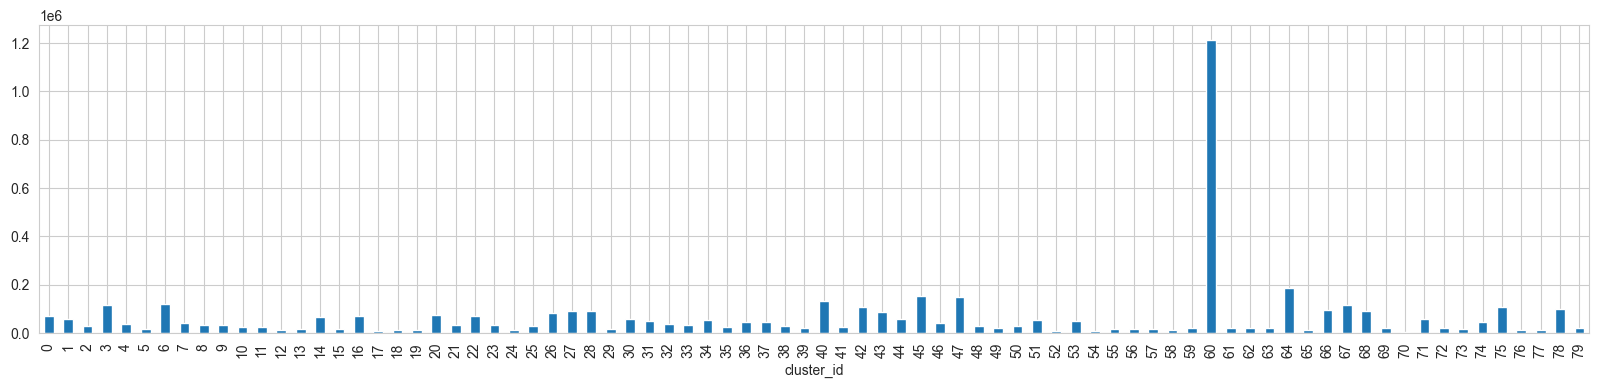

In [46]:
df["cluster_id"].value_counts().sort_index().plot(kind='bar', figsize=(20,4))


### 3.5 Визуализация центров кластеров через PCA

Чтобы увидеть, насколько далеко центры:

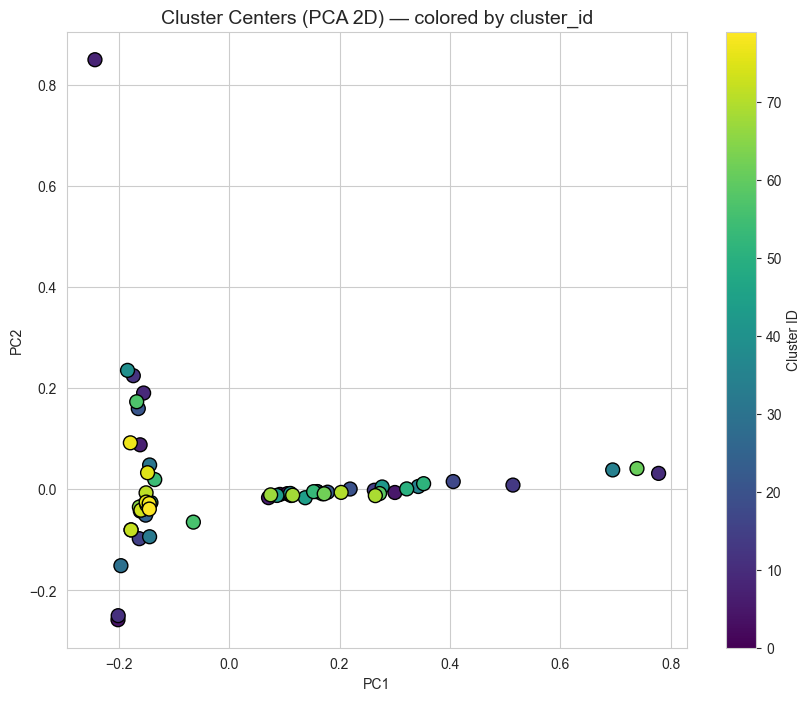

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib import cm, colors

# PCA центров кластеров
pca = PCA(n_components=2)
centers_2d = pca.fit_transform(kmeans.cluster_centers_)

# Количество кластеров
K = kmeans.n_clusters

# Нормализатор от 0 до K-1
norm = colors.Normalize(vmin=0, vmax=K-1)

plt.figure(figsize=(10,8))
plt.scatter(
    centers_2d[:, 0],
    centers_2d[:, 1],
    c=np.arange(K),           # цвет = id кластера
    cmap='viridis',           # можно: plasma, inferno, turbo, rainbow…
    s=100,
    edgecolors='black'
)

plt.colorbar(label="Cluster ID")
plt.title("Cluster Centers (PCA 2D) — colored by cluster_id", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()



### 3.6 Внутрикластерная дисперсия (compactness)

In [48]:
compactness = []

for k in range(kmeans.n_clusters):
    mask = df["cluster_id"] == k
    if mask.sum() == 0:
        continue
    dists = np.linalg.norm(embeddings[mask] - kmeans.cluster_centers_[k], axis=1)
    compactness.append(dists.mean())

print("Средняя внутрикластерная дисперсия:", np.mean(compactness))

#

Средняя внутрикластерная дисперсия: 0.2710605004745502


# 4. Пример проверки предсказания класса

In [34]:
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics.pairwise import cosine_similarity

def embed_text(text):
    """TF-IDF → SVD → embedding"""
    tfidf = vectorizer.transform([text])
    emb = svd.transform(tfidf)
    return emb

# Классический алгоритм KMean
def classify_text(text, top_k=5):

    clean_t = clean_text(text)
    emb = embed_text(clean_t)

    # 1) Предсказанный кластер
    cluster = kmeans.predict(emb)[0]

    # 2) Выгружаем вектор центра
    center = kmeans.cluster_centers_[cluster].reshape(1, -1)

    # 3) Близость текста к центру кластера
    sim_to_center = cosine_similarity(emb, center)[0][0]

    # 4) Находим примеры похожих товаров
    mask = df["cluster_id"] == cluster
    cluster_emb = embeddings[mask]

    sims = cosine_similarity(emb, cluster_emb)[0]
    top_idx = sims.argsort()[-top_k:][::-1]

    examples = df[mask].iloc[top_idx]["DESCRIPTION"].tolist()

    return {
        "cluster": cluster,
        "similarity_to_center": float(sim_to_center),
        "examples": examples
    }

# Топ 3 по KMean
def classify_topn(text, top_k=5, top_clusters=3):

    clean_t = clean_text(text)
    emb = embed_text(clean_t)  # shape (1, dim)

    # 1) similarity ко ВСЕМ центрам
    centers = kmeans.cluster_centers_  # shape (K, dim)
    sims = cosine_similarity(emb, centers)[0]  # shape (K,)

    # 2) топ-3 кластеров
    best_clusters = sims.argsort()[-top_clusters:][::-1]

    results = []

    for cluster in best_clusters:
        sim_to_center = float(sims[cluster])

        # 3) выбираем товары из этого кластера
        mask = df["cluster_id"] == cluster
        cluster_emb = embeddings[mask]

        if len(cluster_emb) == 0:
            examples = []
        else:
            sims_items = cosine_similarity(emb, cluster_emb)[0]
            top_idx = sims_items.argsort()[-top_k:][::-1]
            examples = df[mask].iloc[top_idx]["DESCRIPTION"].tolist()

        results.append({
            "cluster": int(cluster),
            "similarity_to_center": sim_to_center,
            "examples": examples
        })

    return results

# Классифицируем по наибольшей метрике cosine_similarity
def classify_text_cosine(text, top_k=5):
    clean_t = clean_text(text)
    emb = embed_text(clean_t)  # shape: (1, dim)

    # --- 1. similarity ко всем центрам ---
    centers = kmeans.cluster_centers_  # shape: (K, dim)
    sims = cosine_similarity(emb, centers)[0]  # shape: (K,)

    # --- 2. выбираем самый похожий класс ---
    best_cluster = int(sims.argmax())
    best_similarity = float(sims[best_cluster])

    # --- 3. ищем примеры товаров из этого кластера ---
    mask = df["cluster_id"] == best_cluster
    cluster_emb = embeddings[mask]

    if len(cluster_emb) == 0:
        examples = []
    else:
        sims_items = cosine_similarity(emb, cluster_emb)[0]
        top_idx = sims_items.argsort()[-top_k:][::-1]
        examples = df[mask].iloc[top_idx]["DESCRIPTION"].tolist()

    return {
        "cluster": best_cluster,
        "similarity_to_center": best_similarity,
        "examples": examples
    }


def pretty_print(r):
    print(f"\n=== КЛАСТЕР {r['cluster']} ===")
    print(f"Похожесть: {r['similarity_to_center']:.4f}")
    print("Примеры:")
    for ex in r['examples']:
        print(f"   • {ex}")
    print()


## 4.1 Индикация аномальности текста (если он никуда не подходит)
Если similarity_to_center ниже порога → текст аномален.

Обычно:

нормально: 0.5–1.0

подозрительно: 0.3–0.5

совсем не подходит: <0.3

In [35]:
result = classify_text("кроссовки мужские adidas")
pretty_print(result)



=== КЛАСТЕР 60 ===
Похожесть: 0.0982
Примеры:
   • 232068-OLV 10  Кроссовки мужские BOUNDER оливковый р. 10
   • 232068-OLV 7.5  Кроссовки мужские BOUNDER оливковый р. 7.5
   • 232068-OLV 9  Кроссовки мужские BOUNDER оливковый р. 9
   • 232068-OLV 7  Кроссовки мужские BOUNDER оливковый р. 7
   • 232068-OLV 10.5  Кроссовки мужские BOUNDER оливковый р. 10.5



In [36]:
result = classify_text_cosine("кроссовки мужские adidas")
pretty_print(result)


=== КЛАСТЕР 33 ===
Похожесть: 0.3658
Примеры:
   • Кроссовки мужские
   • 114437-T1 41  Кроссовки мужские TSUNAMI 4 M бежевый р. 41
   • 114437-T1 43  Кроссовки мужские TSUNAMI 4 M бежевый р. 43
   • КРОССОВКИ МУЖСКИЕ С.RAGEL MEN 2203
   • КРОССОВКИ МУЖСКИЕ С.RAGEL MEN 2201



In [37]:
import json
res = classify_topn("кроссовки мужские adidas", top_k=5, top_clusters = 5)
for r in res:
    pretty_print(r)


=== КЛАСТЕР 33 ===
Похожесть: 0.3658
Примеры:
   • Кроссовки мужские
   • 114437-T1 41  Кроссовки мужские TSUNAMI 4 M бежевый р. 41
   • 114437-T1 43  Кроссовки мужские TSUNAMI 4 M бежевый р. 43
   • КРОССОВКИ МУЖСКИЕ С.RAGEL MEN 2203
   • КРОССОВКИ МУЖСКИЕ С.RAGEL MEN 2201


=== КЛАСТЕР 60 ===
Похожесть: 0.0982
Примеры:
   • 232068-OLV 10  Кроссовки мужские BOUNDER оливковый р. 10
   • 232068-OLV 7.5  Кроссовки мужские BOUNDER оливковый р. 7.5
   • 232068-OLV 9  Кроссовки мужские BOUNDER оливковый р. 9
   • 232068-OLV 7  Кроссовки мужские BOUNDER оливковый р. 7
   • 232068-OLV 10.5  Кроссовки мужские BOUNDER оливковый р. 10.5


=== КЛАСТЕР 45 ===
Похожесть: 0.0349
Примеры:
   • 822248984-3 Повседневные кроссовки утепленные Серый/черный (5)
   • 822248984-3 Повседневные кроссовки утепленные Серый/черный (6)
   • A20FDESS087-91 41  Кроссовки мужские YANTAY M Men's sport shoes серый р.41
   • 113265-91 41  Кроссовки мужские CHAIN SMR M серый р. 41
   • 113265-91 43.5  Кроссовки мужские 

# 5. Визуализация случайных 50000 кластеров и их сохранение в удобный файл html

In [40]:
import numpy as np
import umap

# подвыборка
N = 50_000
idx = np.random.choice(len(embeddings), N, replace=False)

emb_sample = embeddings[idx]
print("Размер выборки для визуализации:", emb_sample.shape)

print("UMAP до 2D…")

um = umap.UMAP(
    n_neighbors=30,
    n_components=2,
    metric="cosine",
    random_state=42
)

emb2 = um.fit_transform(emb_sample)

df_vis = pd.DataFrame({
    "umap_x": emb2[:, 0],
    "umap_y": emb2[:, 1],
    "cluster": df["cluster_id"].iloc[idx].values,
    "text": df["DESCRIPTION"].iloc[idx].values
})

# 3m 21s

Размер выборки для визуализации: (50000, 200)
UMAP до 2D…


C:\Users\logit\anaconda3\envs\Rhetorics\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [41]:
df_vis

,umap_x,umap_y,cluster,text
0,-6.960984,-2.821817,47,"417738 Щетка для волос с кошачьими ушами, soft..."
1,-13.285104,-11.825214,42,Сервисный сбор по билету №465-2833561068 AKRAM...
2,15.158205,18.453806,42,Сервисный сбор по билету №465-9176295901 BOBB ...
3,5.781471,-2.091003,32,проживание в гостинице: HOTEL CONTINENT HALAL ...
4,-9.134466,-2.424855,60,Перчатки с ПВХ точкой
...,...,...,...,...
49995,4.191821,2.743590,60,хлеб бул изделия
49996,4.126029,-3.594856,21,Transaction fee 465-1402784643 KULBAYEV/KANAT ...
49997,-1.586674,2.639690,64,ПОЛОТЕНЦЕ АРТ СОФТ МАХРОВОЕ UMAI 100*150
49998,4.362555,-5.400767,64,ПОЛОТЕНЦА БУМАЖНЫЕ 1РУЛ 2-Х СЛ


In [42]:
import plotly.express as px

fig = px.scatter(
    df_vis.sample(5000),
    x="umap_x",
    y="umap_y",
    color="cluster",
    hover_data=["text"],
    opacity=0.7
)

fig.update_traces(marker=dict(size=5))

fig.write_html("umap_vis.html")

print("Готово: файл создан → umap_vis.html. Для анализа графика можете рассмотреть его подробнее в корне проекта")


Готово: файл создан → umap_vis.html. Для анализа графика можете рассмотреть его подробнее в корне проекта


# 6. Дообучение модели для новых классов

In [ ]:
new_texts = [
    "новый товар пример 1",
    "спортивные мужские ботинки",
    "зимняя обувь кожаная"
]
# или
#df_new = pd.read_csv("new_data.csv")
#new_texts = df_new["DESCRIPTION"].astype(str).tolist()

In [ ]:
def embed_list(text_list):
    clean_list = [clean_text(t) for t in text_list]
    tfidf = vectorizer.transform(clean_list)
    emb = svd.transform(tfidf)
    return emb

In [ ]:
new_emb = embed_list(new_texts)   # shape (N, 200)

In [ ]:
# Создаём новый кластер (на основе обученных)
def add_new_cluster_batch(new_emb):
    global kmeans

    # 1. Берём средний вектор новых эмбеддингов как центр
    new_center = new_emb.mean(axis=0, keepdims=True)

    old_centers = kmeans.cluster_centers_
    updated_centers = np.vstack([old_centers, new_center])

    # 2. Обновляем модель
    kmeans.cluster_centers_ = updated_centers
    kmeans.n_clusters = updated_centers.shape[0]

    # 3. Несколько шагов стабилизации
    for _ in range(50):
        kmeans.partial_fit(new_emb)

    print(f"Создан новый кластер #{kmeans.n_clusters - 1}")

    return kmeans.n_clusters - 1

# Добавляем новые данные в общий датасет
def update_dataset(new_texts, new_emb, new_cluster_id):

    global df, embeddings

    clean_list = [clean_text(t) for t in new_texts]

    # Добавить строки
    for clean_text_val, emb_val in zip(clean_list, new_emb):
        df.loc[len(df)] = {
            "DESCRIPTION": clean_text_val,
            "cluster_id": new_cluster_id
        }

    # Обновить embeddings.npy
    embeddings = np.vstack([embeddings, new_emb])
    np.save("embeddings_svd.npy", embeddings)

    # Сохранить CSV
    df.to_csv("data_KNN.csv", index=False)

# Полный пайплайн дообучения модели и добавление вручную нового кластера
def retrain_with_new_data(new_texts):
    print("→ Чистим и векторизуем тексты…")
    new_emb = embed_list(new_texts)

    print("→ Создаём новый кластер…")
    new_cluster_id = add_new_cluster_batch(new_emb)

    print("→ Записываем новые данные в датасет…")
    update_dataset(new_texts, new_emb, new_cluster_id)

    print("→ Сохраняем обновлённую модель…")
    joblib.dump(kmeans, "kmeans_updated.joblib")

    print(f"ГОТОВО! Добавлен новый кластер #{new_cluster_id}")
